# 1. Import some libraries

In [1]:
import pyspark
import numpy as np
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import os
import pandas as pd
from plotnine import *

os.getcwd()
path = '/Users/estevaoprado/Documents/GitHub/MH-with-flexible-sub-sampling/03_paper_revision/kagglehub/datasets/thedevastator/uncovering-insights-from-electronic-card-transac/versions/2'
os.chdir(path)

# Create SparkSession 
spark = SparkSession.builder \
      .master("local[1]") \
      .appName("PoissonNonIIDExample") \
      .getOrCreate() 

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/02/18 00:09:42 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


# 2. Read and clean the time series data

In [2]:
# Read the csv files
months = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

df_1 = spark.read.options(inferSchema=True, header=True).csv('ect-jan2019-csv-tables.csv')
df_2 = spark.read.options(inferSchema=True, header=True).csv('ect-feb2019-csv-tables.csv')
df_3 = spark.read.options(inferSchema=True, header=True).csv('ect-mar2019-csv-tables.csv')
df_4 = spark.read.options(inferSchema=True, header=True).csv('ect-apr2019-csv-tables.csv')

df_1 = df_1.withColumn('month', F.lit('jan'))
df_2 = df_2.withColumn('month', F.lit('feb'))
df_3 = df_3.withColumn('month', F.lit('mar'))
df_4 = df_4.withColumn('month', F.lit('apr'))

df = df_1.unionByName(df_2).unionByName(df_3).unionByName(df_4)

print(df.count()) # number of rows

df.show()
# Filter out missing values
df = df.filter(~(F.col('STATUS') == 'C') &
               (F.col('UNITS') == 'Dollars') &
               (F.col('Data_value').isNotNull()))

# Columns that seem to matter
df = df.select('index', 'period', 'Data_value', 'STATUS', 'month')
df_pd = df.toPandas()

63406
+-----+----------------+-------+----------+----------+------+-------+---------+--------------------+--------------------+--------------+--------------------+--------------+--------------+--------------+-----+
|index|Series_reference| Period|Data_value|Suppressed|STATUS|  UNITS|Magnitude|             Subject|               Group|Series_title_1|      Series_title_2|Series_title_3|Series_title_4|Series_title_5|month|
+-----+----------------+-------+----------+----------+------+-------+---------+--------------------+--------------------+--------------+--------------------+--------------+--------------+--------------+-----+
|    0|      ECTA.S19A1|2001.03|      NULL|      NULL|     C|Dollars|        6|Electronic Card T...|Total values - El...|        Actual|RTS total industries|          NULL|          NULL|          NULL|  jan|
|    1|      ECTA.S19A1|2002.03|      NULL|      NULL|     C|Dollars|        6|Electronic Card T...|Total values - El...|        Actual|RTS total industries| 

# 3. Visualise time series

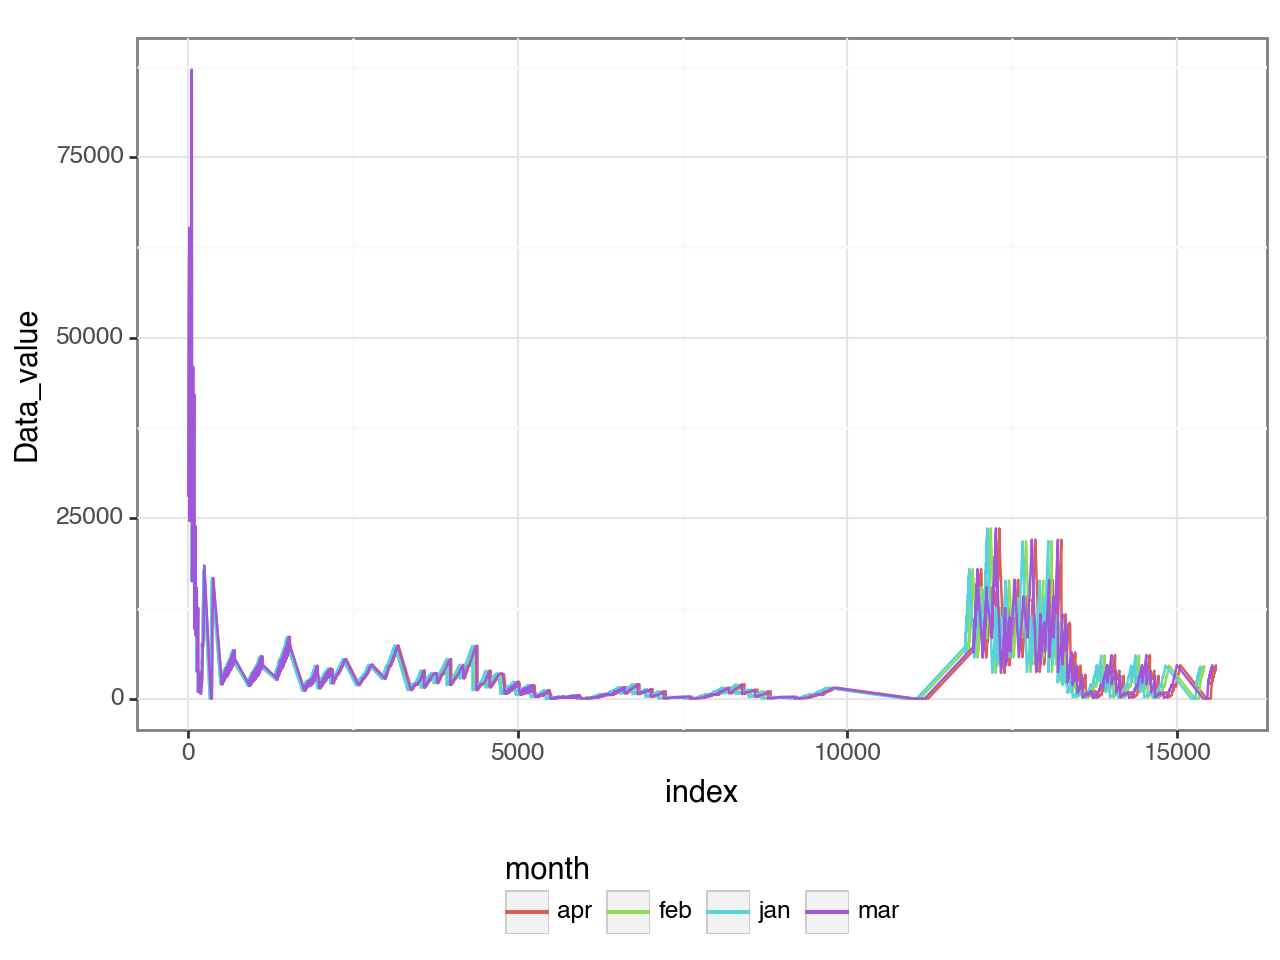

<Figure Size: (640 x 480)>

In [3]:
(
    ggplot(data=df_pd, mapping=aes(x='index', y='Data_value', color='month'))
    + geom_line()
    + theme_bw()
    + theme(
        legend_position='bottom'
    )
 )

# 4. Calculate autocorrelation

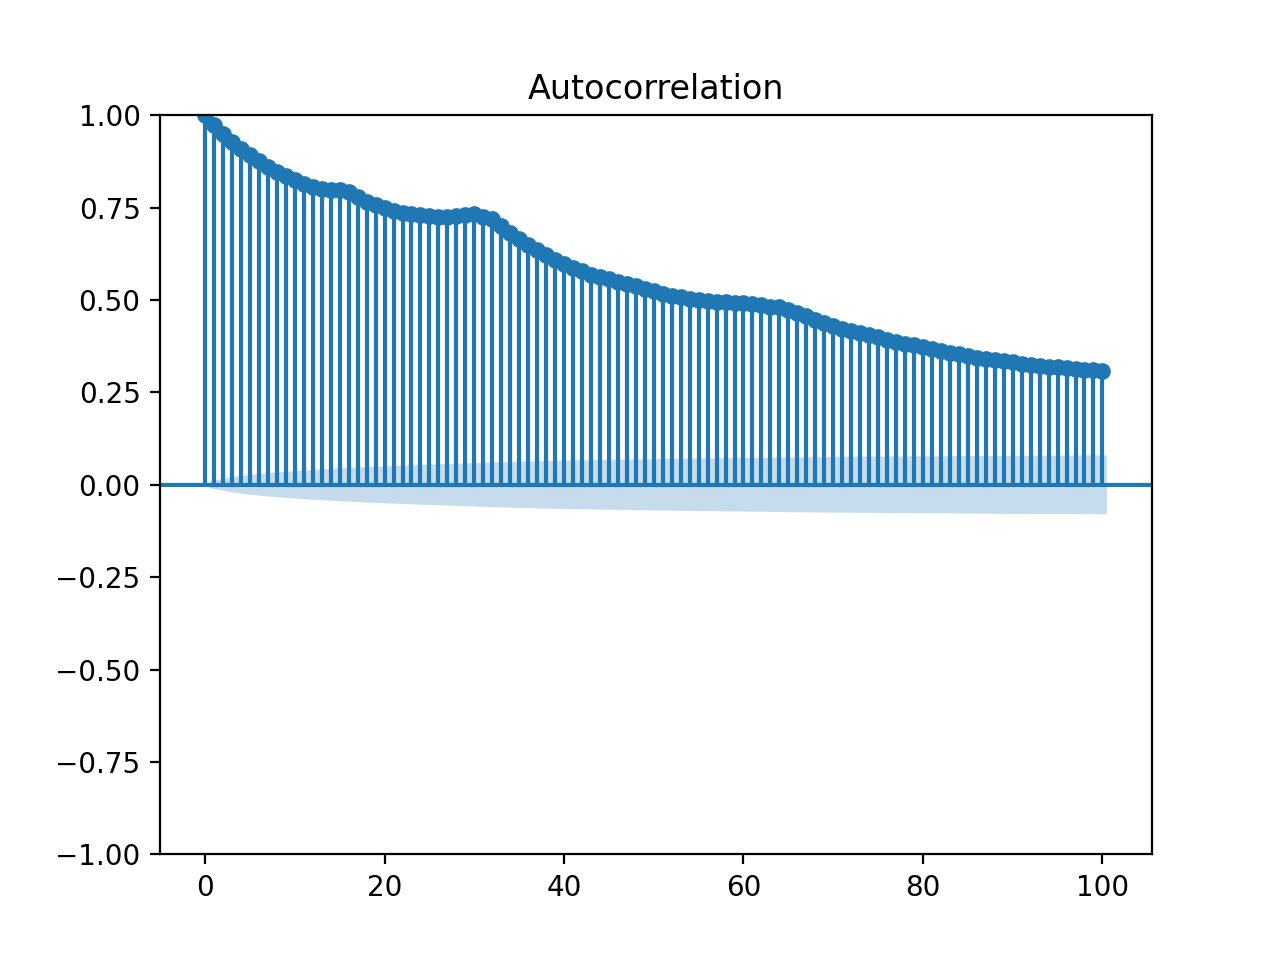

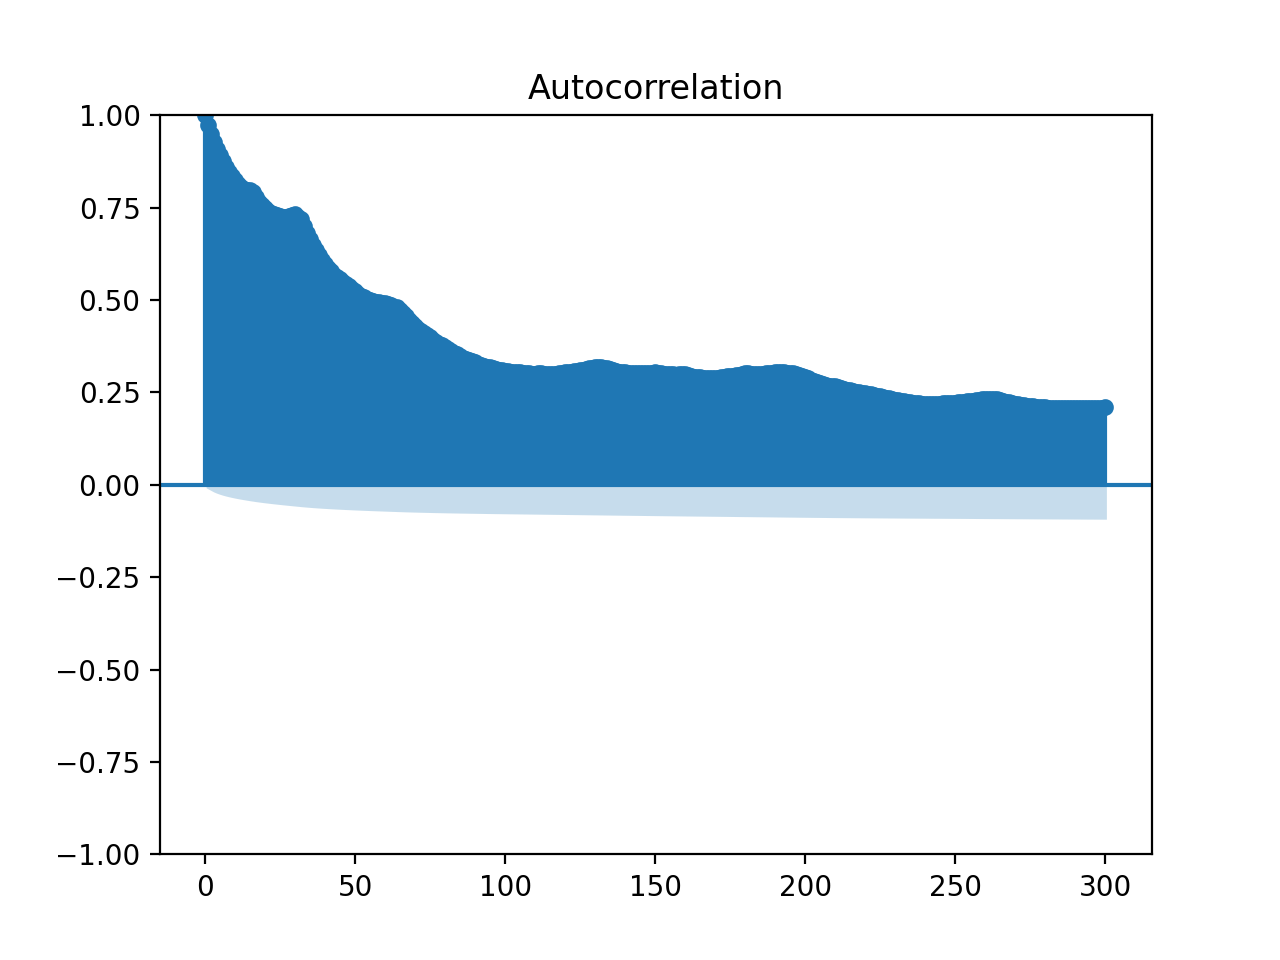

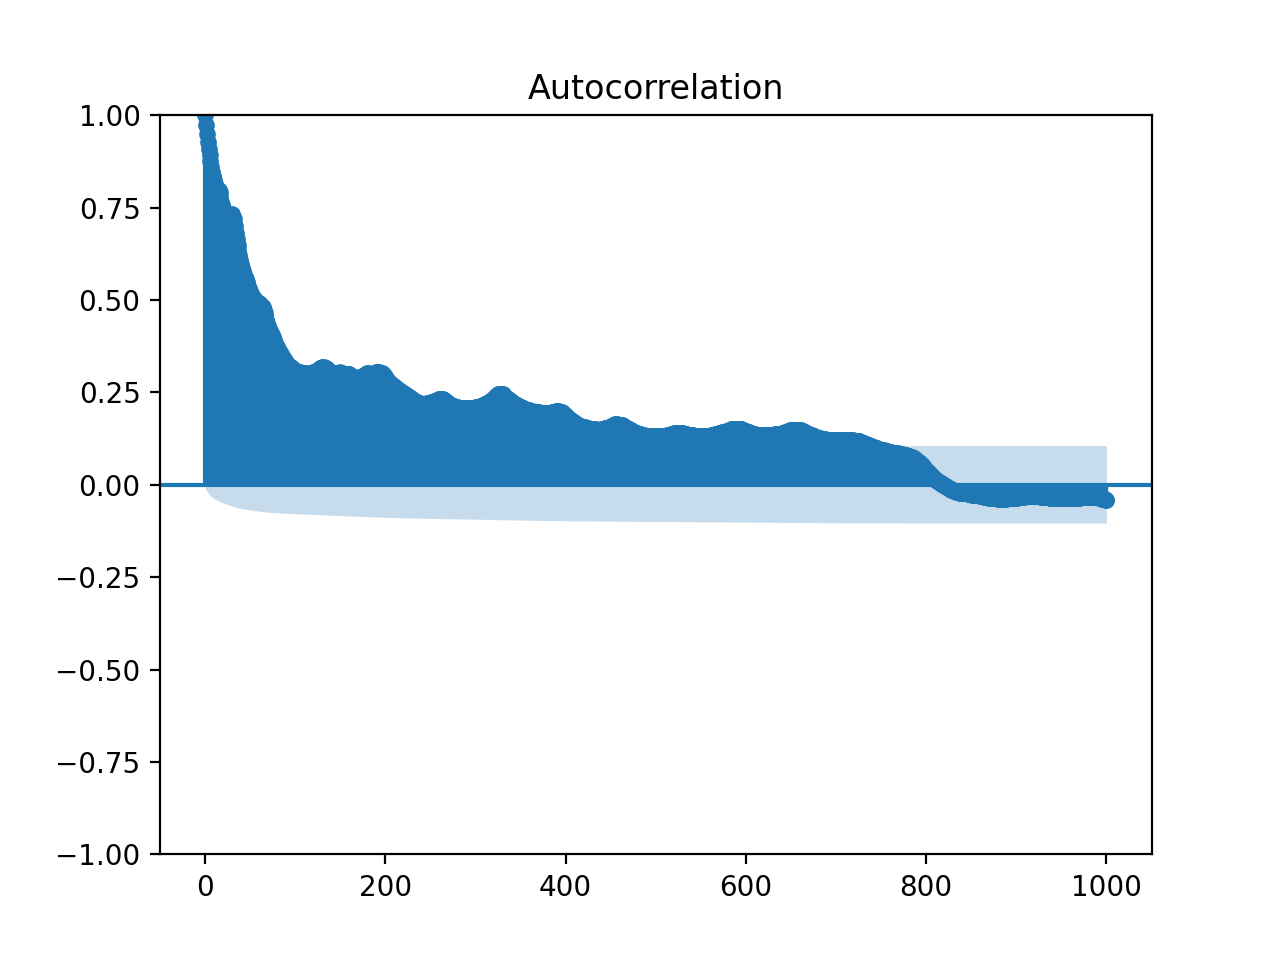

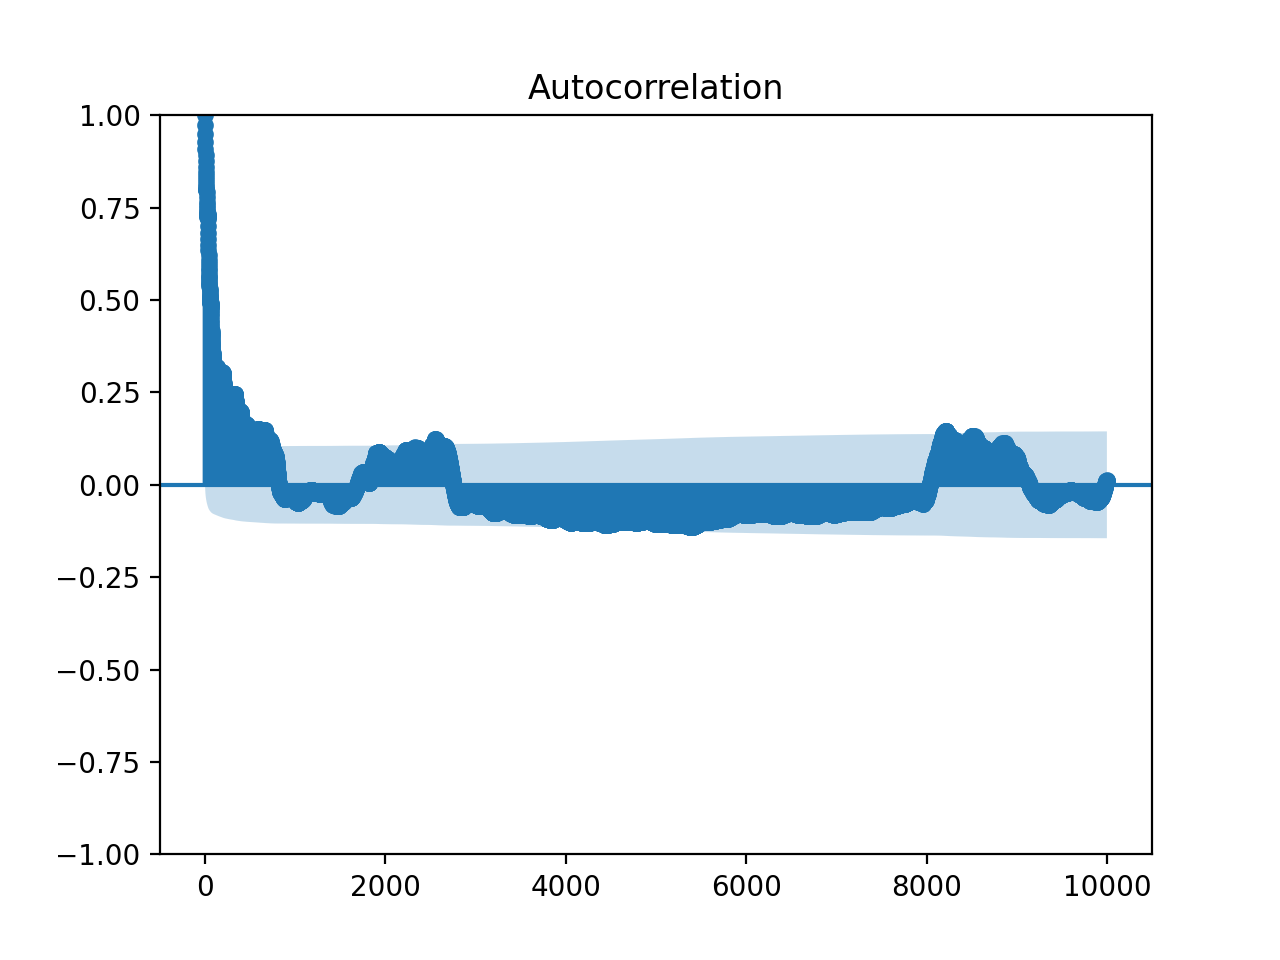

25/02/18 01:01:54 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 1920125 ms exceeds timeout 120000 ms
25/02/18 01:01:54 WARN SparkContext: Killing executors is not supported by current scheduler.
25/02/18 01:01:58 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1223)
	at 

In [4]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
from statsmodels.graphics import tsaplots

# data = np.array(df.filter(F.col('month') == 'jan').toPandas()['Data_value'])
data = np.array(df.toPandas()['Data_value'])

fig = tsaplots.plot_acf(data, lags=100)
plt.show()

fig = tsaplots.plot_acf(data, lags=300)
plt.show()

fig = tsaplots.plot_acf(data, lags=1000)
plt.show()

fig = tsaplots.plot_acf(data, lags=10000)
plt.show()